In [3]:
!pip install pytorch_tabnet -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.9 MB/s eta 0:00:00


In [4]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print("Not running on Colab — using local data path.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Imports & Setup



In [5]:

import polars as pl
import numpy as np
import os, re, random, time

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    mean_absolute_error, mean_squared_error,
)

import torch
from pytorch_tabnet.tab_model import TabNetClassifier, TabNetRegressor
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*pin_memory.*")
warnings.filterwarnings("ignore", message=".*Best weights from best epoch.*")

if torch.cuda.is_available():
    device_name = "cuda"
elif torch.backends.mps.is_available():
    device_name = "mps"
else:
    device_name = "cpu"
print(f"Using device: {device_name}")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

Using device: cuda


In [6]:
import polars as pl
import os


def _get_base_path():
    if os.path.isdir("/content/drive/MyDrive"):
        return "/content/drive/MyDrive/Post-Earnings/model_staging"
    return "../data/model_staging"


def build_modeling_table(base_path: str = _get_base_path()) -> pl.DataFrame:
    """
    Loads and joins tech, fundamental, FinBERT, and news sentiment tables,
    plus one-hot encoded sector flags, into a single modeling DataFrame.
    """
    # Technical features (base table)
    df_tech = pl.read_parquet(f"{base_path}/tech_modeling_table.parquet")

    # Fundamental indicators
    df_fund = pl.read_parquet(f"{base_path}/fundamentalIndicators/modeling_fundamentals.parquet")
    df_fund = df_fund.select([
        "symbol",
        pl.col("reportedDate").alias("earnings_date"),
        "eps_growth_qoq", "revenue_growth_qoq",
        "gross_margin",     "gross_margin_qoq",
        "debt_to_equity",   "debt_to_equity_qoq",
        "fcf_margin",       "fcf_margin_qoq",
        "roe",              "roe_qoq",
        "surprisePercentage",
    ])

    # FinBERT sentiment
    df_finbert = pl.read_parquet(f"{base_path}/finbert_tx_agg_weighted.parquet")
    df_finbert_feat = df_finbert.select([
        "symbol",
        pl.col("reportedDate").alias("earnings_date"),
        "pos_prob", "neg_prob",
    ])

    # News sentiment (pre/post)
    df_nz = pl.read_parquet(f"{base_path}/nz_sentiment.parquet")
    df_nz = df_nz.select([
        "symbol",
        pl.col("reportedDate").alias("earnings_date"),
        "overall_sentiment_score_pre",  "ticker_sentiment_score_pre",
        "overall_sentiment_score_post", "ticker_sentiment_score_post",
    ])

    # Join everything on symbol + earnings_date
    df_model = (
        df_tech
        .join(df_fund,       on=["symbol", "earnings_date"], how="left")
        .join(df_finbert_feat, on=["symbol", "earnings_date"], how="left")
        .join(df_nz,          on=["symbol", "earnings_date"], how="left")
    )

    # Sector one-hot encoding (reuses df_finbert since it's already loaded)
    df_sector = df_finbert.select(["symbol", "sector"]).unique()
    df_sector = df_sector.with_columns(pl.col("sector").fill_null("Unknown"))
    sectors = sorted(df_sector["sector"].unique().to_list())
    df_sector = df_sector.with_columns([
        (pl.col("sector") == s).cast(pl.Int8).alias(f"sector_{s.replace(' ', '_')}")
        for s in sectors
    ]).drop("sector")

    df_model = df_model.join(df_sector, on="symbol", how="left")

    print(f"Tech table shape: {df_tech.shape}")
    print(f"Combined table shape: {df_model.shape}")
    print(f"Target class distribution:\n{df_model['target_class'].value_counts().sort('target_class')}")

    return df_model

df_model = build_modeling_table()

Tech table shape: (24048, 239)
Combined table shape: (24048, 268)
Target class distribution:
shape: (3, 2)
┌──────────────┬───────┐
│ target_class ┆ count │
│ ---          ┆ ---   │
│ i64          ┆ u32   │
╞══════════════╪═══════╡
│ 0            ┆ 7955  │
│ 1            ┆ 6428  │
│ 2            ┆ 9665  │
└──────────────┴───────┘


In [7]:
df_model.schema

Schema([('symbol', String),
        ('earnings_date', Date),
        ('entry_price', Float64),
        ('target_return', Float64),
        ('target_class', Int64),
        ('car_3day', Float64),
        ('car_t2_t10', Float64),
        ('max_high', Float64),
        ('min_high', Float64),
        ('max_day', Int64),
        ('min_day', Int64),
        ('open_pct_t-10', Float64),
        ('high_pct_t-10', Float64),
        ('low_pct_t-10', Float64),
        ('volume_rel_t-10', Float64),
        ('rsi_t-10', Float64),
        ('macd_t-10', Float64),
        ('macd_hist_t-10', Float64),
        ('roc_t-10', Float64),
        ('ema50_pct_t-10', Float64),
        ('ema200_pct_t-10', Float64),
        ('ema50_200_pct_t-10', Float64),
        ('adx_t-10', Float64),
        ('atr_t-10', Float64),
        ('bb_width_t-10', Float64),
        ('bb_pct_b_t-10', Float64),
        ('sigma_t-10', Float64),
        ('obv_zscore_t-10', Float64),
        ('vwap_pct_t-10', Float64),
        ('vix_close_t

In [8]:
df_model.describe()

statistic,symbol,earnings_date,entry_price,target_return,target_class,car_3day,car_t2_t10,max_high,min_high,max_day,min_day,open_pct_t-10,high_pct_t-10,low_pct_t-10,volume_rel_t-10,rsi_t-10,macd_t-10,macd_hist_t-10,roc_t-10,ema50_pct_t-10,ema200_pct_t-10,ema50_200_pct_t-10,adx_t-10,atr_t-10,bb_width_t-10,bb_pct_b_t-10,sigma_t-10,obv_zscore_t-10,vwap_pct_t-10,vix_close_t-10,open_pct_t-9,high_pct_t-9,low_pct_t-9,volume_rel_t-9,rsi_t-9,macd_t-9,…,adx_t+1,atr_t+1,bb_width_t+1,bb_pct_b_t+1,sigma_t+1,obv_zscore_t+1,vwap_pct_t+1,vix_close_t+1,eps_growth_qoq,revenue_growth_qoq,gross_margin,gross_margin_qoq,debt_to_equity,debt_to_equity_qoq,fcf_margin,fcf_margin_qoq,roe,roe_qoq,surprisePercentage,pos_prob,neg_prob,overall_sentiment_score_pre,ticker_sentiment_score_pre,overall_sentiment_score_post,ticker_sentiment_score_post,sector_Basic_Materials,sector_Communication_Services,sector_Consumer_Cyclical,sector_Consumer_Defensive,sector_Energy,sector_Financial_Services,sector_Healthcare,sector_Industrials,sector_Real_Estate,sector_Technology,sector_Unknown,sector_Utilities
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""24048""","""24048""",24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,…,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,23575.0,23728.0,23735.0,23728.0,23725.0,23711.0,23735.0,23726.0,23727.0,23713.0,23958.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0,24048.0
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,473.0,320.0,313.0,320.0,323.0,337.0,313.0,322.0,321.0,335.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,"""2020-04-24 05:52:52.455089""",121.206692,0.042991,1.071108,0.003473,0.001891,126.300971,119.759447,6.103418,5.65756,-0.000403,0.011146,-0.011794,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.220952,0.00007,0.011174,-0.011465,NaN,NaN,NaN,…,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.970897,NaN,0.03324,NaN,NaN,1.625189,0.005672,0.118356,0.001137,0.049569,-0.001809,8.76362,NaN,NaN,0.182376,0.186482,0.180166,0.184441,0.039587,0.046324,0.10741,0.068239,0.04229,0.14022,0.118305,0.146166,0.063249,0.160637,0.004948,0.062625
"""std""",null,null,259.178843,0.045487,0.853039,0.061556,0.049086,269.134045,255.132553,3.082486,2.961256,0.016397,0.011899,0.011279,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.584572,0.015917,0.011947,0.0109,NaN,NaN,NaN,…,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.117381,NaN,0.248282,NaN,NaN,1.358347,0.792222,0.342877,0.482301,0.305485,0.32769,37.393079,NaN,NaN,0.158855,0.167164,0.163866,0.174395,0.194992,0.21019,0.30964,0.25216,0.201255,0.347222,0.322976,0.35328,0.243414,0.367203,0.070172,0.242292
"""min""","""A""","""2014-01-07""",0.409201,-0.131541,0.0,-0.538946,-0.747742,0.444908,0.423108,2.0,2.0,-0.184386,-1.3261e-16,-0.186799,-1.0,5.362353,-0.65245,-0.093847,-55.801106,-0.629462,-0.817439,-0.778971,5.779679,0.001758,0.002447,-0.378107,0.000691,-6.861212,-0.407643,9.15,-0.160652,-1.4629e-16,-0.160652,-1.0,5.362353,-0.641054,…,7.434718,0.002523,0.0,-0.397097,0.0,-7.83209,-0.413632,9.14,-5.0,-5.0,-1.0,-1.0,-3.0,-3.0,-3.0,-5.0,-3.0,-3.0,-200.0,0.013188,0.023734,-0.842745,-0.948116,-0.823871,-0.839928,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",null,"""2017-04-13""",37.826977,0.014795,0.0,-0.029

In [9]:
# df_model

# # # ── Overwrite target_class with wider thresholds (1% / 5%) ────────
# # df_model = df_model.with_columns(
# #     pl.when(pl.col("target_return") < 0.01).then(0)
# #     .when(pl.col("target_return") < 0.05).then(1)
# #     .otherwise(2).alias("target_class")
# # )

# print("New class distribution (0:<1%, 1:1-5%, 2:>=5%):")
# print(df_model["target_class"].value_counts().sort("target_class"))


## 2. Feature List

Drop `car_*` leakage columns, add year/quarter for fold splitting, then build a flat 257-feature vector with sequence columns grouped and ordered by timestep.

In [10]:
# Drop car_* columns (leakage)
df_model = df_model.drop([col for col in df_model.columns if col.startswith("car")])

# Add year/quarter columns for fold construction
df_model = df_model.with_columns([
    pl.col("earnings_date").dt.year().alias("year"),
    pl.col("earnings_date").dt.quarter().alias("quarter"),
])

# Filter to 2025
df_model = df_model.filter(pl.col("year") <= 2025)

# Label-encode symbol (single integer column, not one-hot)
df_model = df_model.with_columns(
    pl.col("symbol").cast(pl.Categorical).to_physical().alias("symbol_enc")
)

EXCLUDE_COLS = [
    "symbol", "earnings_date", "entry_price", "target_return",
    "target_class", "max_high", "min_high", "max_day", "min_day", "year", "quarter",
]
feature_cols = [c for c in df_model.columns if c not in EXCLUDE_COLS]

TECH_BASES = [
    "rsi", "macd", "macd_hist", "roc",
    "ema50_pct", "ema200_pct", "ema50_200_pct", "adx",
    "atr", "bb_width", "bb_pct_b", "sigma",
    "obv_zscore", "vwap_pct",
    "open_pct", "high_pct", "low_pct", "volume_rel",
]
VIX_BASES = ["vix_close"]
SEQ_BASES = TECH_BASES + VIX_BASES  # 19 indicators × 12 timesteps

def group_sequence_columns(all_cols, bases):
    """Group columns by base indicator, ordered by timestep."""
    groups = {}
    remaining = list(all_cols)
    for base in sorted(bases, key=len, reverse=True):
        matched = [c for c in remaining if c == base or c.startswith(base + "_")]
        def step_key(col, base=base):
            m = re.search(r"(-?\d+)", col[len(base):])
            return int(m.group(1)) if m else 0
        groups[base] = sorted(matched, key=step_key)
        remaining = [c for c in remaining if c not in matched]
    return {base: groups[base] for base in bases}

seq_groups = group_sequence_columns(feature_cols, SEQ_BASES)
timestep_counts = {len(c) for c in seq_groups.values()}
assert len(timestep_counts) == 1, f"Inconsistent timestep counts: {timestep_counts}"
n_timesteps = timestep_counts.pop()
seq_cols_ordered = [c for base in SEQ_BASES for c in seq_groups[base]]

other_cols = [c for c in feature_cols if c not in seq_cols_ordered]
flat_feature_cols = seq_cols_ordered + other_cols

assert len(flat_feature_cols) == len(feature_cols), (
    f"Feature count mismatch: flat={len(flat_feature_cols)}, original={len(feature_cols)}"
)
print(f"Sequence block: {len(seq_cols_ordered)} cols ({len(SEQ_BASES)} indicators × {n_timesteps} steps)")
print(f"Other (fundamentals/sentiment/sector): {len(other_cols)} cols")
print(f"Total flat features: {len(flat_feature_cols)}")

Sequence block: 228 cols (19 indicators × 12 steps)
Other (fundamentals/sentiment/sector): 30 cols
Total flat features: 258


## 3. Fold Construction — Quarterly Expanding Window

Same expanding-window walk-forward pattern: train = everything before the validation quarter, val = the single quarter immediately before test (TabNet requires a validation set for early stopping), test = the held-out quarter. Imputer and scaler are fit on train only. First test quarter is **2021_Q1** (7 years initial training: 2014–2020).

Dataset spans: 2014-01-07 to 2025-12-19
Total rows: 23106

EXPANDING WINDOW FOLD CONSTRUCTION (val = quarter before test)
Initial training period: 2014–2020 (7 yrs)
Testing begins at: {'year': 2021, 'quarter': 1}



Fold  1 [2021_Q1]:  train=12,683  val= 486 (2020_Q4)  test= 492
Fold  2 [2021_Q2]:  train=13,169  val= 492 (2021_Q1)  test= 493
Fold  3 [2021_Q3]:  train=13,661  val= 493 (2021_Q2)  test= 493
Fold  4 [2021_Q4]:  train=14,154  val= 493 (2021_Q3)  test= 492
Fold  5 [2022_Q1]:  train=14,647  val= 492 (2021_Q4)  test= 494
Fold  6 [2022_Q2]:  train=15,139  val= 494 (2022_Q1)  test= 495
Fold  7 [2022_Q3]:  train=15,633  val= 495 (2022_Q2)  test= 493
Fold  8 [2022_Q4]:  train=16,128  val= 493 (2022_Q3)  test= 493
Fold  9 [2023_Q1]:  train=16,621  val= 493 (2022_Q4)  test= 492
Fold 10 [2023_Q2]:  train=17,114  val= 492 (2023_Q1)  test= 498
Fold 11 [2023_Q3]:  train=17,606  val= 498 (2023_Q2)  test= 496
Fold 12 [2023_Q4]:  train=18,104  val= 496 (2023_Q3)  test= 498
Fold 13 [2024_Q1]:  train=18,600  val= 498 (2023_Q4)  test= 496
Fold 14 [2024_Q2]:  train=19,098  val= 496 (2024_Q1)  test= 501
Fold 15 [2024_Q3]:  train=19,594  val= 501 (2024_Q2)  test= 499
Fold 16 [2024_Q4]:  train=20,095  val= 4

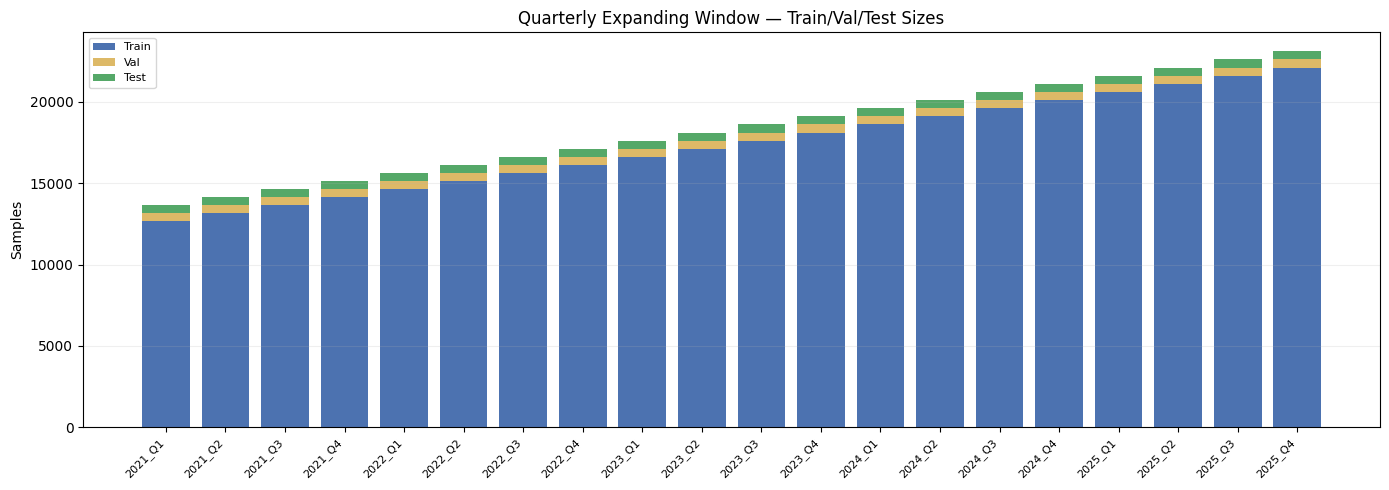

In [58]:
def prep_block(train_df, val_df, test_df, cols):
    """Fit imputer + scaler on train ONLY. Val and test are transform-only."""
    Xtr = train_df.select(cols).to_numpy()
    Xva = val_df.select(cols).to_numpy()
    Xte = test_df.select(cols).to_numpy()

    Xtr = np.where(np.isinf(Xtr), np.nan, Xtr)
    Xva = np.where(np.isinf(Xva), np.nan, Xva)
    Xte = np.where(np.isinf(Xte), np.nan, Xte)

    imputer = SimpleImputer(strategy="median").fit(Xtr)
    Xtr = imputer.transform(Xtr)
    Xva = imputer.transform(Xva)
    Xte = imputer.transform(Xte)

    scaler = StandardScaler().fit(Xtr)
    return (
        scaler.transform(Xtr).astype(np.float32),
        scaler.transform(Xva).astype(np.float32),
        scaler.transform(Xte).astype(np.float32),
    )


INITIAL_TRAIN_YEARS = 7  # 2014–2020

min_date = df_model["earnings_date"].min()
max_date = df_model["earnings_date"].max()
print(f"Dataset spans: {min_date} to {max_date}")
print(f"Total rows: {len(df_model)}\n")

unique_quarters = df_model.select(["year", "quarter"]).unique().sort(["year", "quarter"])
quarters_list = unique_quarters.to_dicts()

print("=" * 100)
print("EXPANDING WINDOW FOLD CONSTRUCTION (val = quarter before test)")
print("=" * 100)

earliest_year = quarters_list[0]["year"]
initial_train_end_year = earliest_year + INITIAL_TRAIN_YEARS - 1  # 2020
first_test_idx = next(i for i, q in enumerate(quarters_list) if q["year"] > initial_train_end_year)

print(f"Initial training period: {earliest_year}\u2013{initial_train_end_year} ({INITIAL_TRAIN_YEARS} yrs)")
print(f"Testing begins at: {quarters_list[first_test_idx]}")
print("=" * 100 + "\n")

folds_data = []
fold_meta = []
fold_num = 1

for test_quarter_idx in range(first_test_idx, len(quarters_list)):
    test_q = quarters_list[test_quarter_idx]
    val_q  = quarters_list[test_quarter_idx - 1]
    test_label = f"{test_q['year']}_Q{test_q['quarter']}"

    test_data = df_model.filter(
        (pl.col("year") == test_q["year"]) & (pl.col("quarter") == test_q["quarter"])
    )
    val_data = df_model.filter(
        (pl.col("year") == val_q["year"]) & (pl.col("quarter") == val_q["quarter"])
    )
    train_data = df_model.filter(
        (pl.col("year") < val_q["year"]) |
        ((pl.col("year") == val_q["year"]) & (pl.col("quarter") < val_q["quarter"]))
    )

    if len(train_data) == 0 or len(val_data) == 0 or len(test_data) == 0:
        continue

    X_tr, X_va, X_te = prep_block(train_data, val_data, test_data, flat_feature_cols)

    folds_data.append({
        "fold_num":     fold_num,
        "test_quarter": test_label,
        "X_train":      X_tr,
        "X_val":        X_va,
        "X_test":       X_te,
        "y_train_cls":  train_data["target_class"].to_numpy(),
        "y_val_cls":    val_data["target_class"].to_numpy(),
        "y_test_cls":   test_data["target_class"].to_numpy(),
        "symbol":         test_data["symbol"].to_numpy(),
        "earnings_date":  test_data["earnings_date"].to_numpy(),
        "y_train_ret":    train_data["target_return"].to_numpy(),
        "y_val_ret":      val_data["target_return"].to_numpy(),
        "y_test_ret":     test_data["target_return"].to_numpy(),
    })

    fold_meta.append({
        "quarter": test_label,
        "train": X_tr.shape[0],
        "val": X_va.shape[0],
        "test": X_te.shape[0],
    })

    print(f"Fold {fold_num:2d} [{test_label}]:  "
          f"train={X_tr.shape[0]:6,}  "
          f"val={X_va.shape[0]:4,} ({val_q['year']}_Q{val_q['quarter']})  "
          f"test={X_te.shape[0]:4,}")

    fold_num += 1

n_features = len(flat_feature_cols)
print("=" * 100)
print(f"Total folds: {len(folds_data)}")
print(f"n_features: {n_features}")
print("=" * 100)

# ── Fold-size bar chart ──────────────────────────────────────────────
fold_labels = [m["quarter"] for m in fold_meta]
train_sizes = [m["train"] for m in fold_meta]
val_sizes   = [m["val"] for m in fold_meta]
test_sizes  = [m["test"] for m in fold_meta]

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(fold_labels))
ax.bar(x, train_sizes, label="Train", color="#4C72B0")
ax.bar(x, val_sizes,   bottom=train_sizes, label="Val", color="#DDB967")
ax.bar(x, test_sizes,  bottom=np.array(train_sizes) + np.array(val_sizes), label="Test", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(fold_labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Samples")
ax.set_title("Quarterly Expanding Window — Train/Val/Test Sizes")
ax.legend(fontsize=8)
ax.grid(alpha=0.2, axis="y")
plt.tight_layout()
plt.show()

## 4. TabNet — Training Functions

Separate classifier (`train_tabnet_clf`) and regressor (`train_tabnet_reg`) with fixed defaults (no tuning). Both use early stopping on the validation quarter. Device set to MPS for Mac local execution.

In [ ]:

CLF_DEFAULTS = dict(
    n_d=16, n_a=16, n_steps=3, gamma=1.5,
    lambda_sparse=1e-3, lr=2e-2, step_size=30,
    scheduler_gamma=0.9, max_epochs=60, patience=8,
    batch_size=4096, clip_value=2.0, seed=42,
)

REG_DEFAULTS = dict(
    n_d=16, n_a=16, n_steps=3, gamma=1.5,
    lambda_sparse=1e-3, lr=5e-3, step_size=30,
    scheduler_gamma=0.9, max_epochs=60, patience=8,
    batch_size=4096, clip_value=2.0, seed=42,
)


def train_tabnet_clf(f, **kwargs):
    """Train TabNet classifier with early stopping on validation quarter."""
    cfg = CLF_DEFAULTS | kwargs
    set_seed(cfg["seed"])

    clf = TabNetClassifier(
        n_d=cfg["n_d"], n_a=cfg["n_a"], n_steps=cfg["n_steps"], gamma=cfg["gamma"],
        lambda_sparse=cfg["lambda_sparse"],
        clip_value=cfg["clip_value"],
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=cfg["lr"]),
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params=dict(step_size=cfg["step_size"], gamma=cfg["scheduler_gamma"]),
        mask_type="entmax",
        verbose=0,
        seed=cfg["seed"],
        device_name=device_name,
    )

    clf.fit(
        X_train=f["X_train"], y_train=f["y_train_cls"],
        eval_set=[(f["X_val"], f["y_val_cls"])],
        eval_name=["val"], eval_metric=["logloss"],
        max_epochs=cfg["max_epochs"], patience=cfg["patience"],
        batch_size=cfg["batch_size"], virtual_batch_size=128,
        weights=1,
    )

    test_probs = clf.predict_proba(f["X_test"])
    test_preds = test_probs.argmax(axis=1)

    return {
        "clf_preds":  test_preds,
        "clf_probs":  test_probs,
        "best_epoch": clf.best_epoch,
        "model":      clf,
        "history":    clf.history,
    }


def train_tabnet_reg(f, **kwargs):
    """Train TabNet regressor with early stopping on validation quarter."""
    cfg = REG_DEFAULTS | kwargs
    set_seed(cfg["seed"])

    reg = TabNetRegressor(
        n_d=cfg["n_d"], n_a=cfg["n_a"], n_steps=cfg["n_steps"], gamma=cfg["gamma"],
        lambda_sparse=cfg["lambda_sparse"],
        clip_value=cfg["clip_value"],
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=cfg["lr"]),
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params=dict(step_size=cfg["step_size"], gamma=cfg["scheduler_gamma"]),
        mask_type="entmax",
        verbose=0,
        seed=cfg["seed"],
        device_name=device_name,
    )

    y_mean, y_std = f["y_train_ret"].mean(), f["y_train_ret"].std()
    y_train_scaled = ((f["y_train_ret"] - y_mean) / y_std).reshape(-1, 1).astype(np.float32)
    y_val_scaled   = ((f["y_val_ret"]   - y_mean) / y_std).reshape(-1, 1).astype(np.float32)

    reg.fit(
        X_train=f["X_train"], y_train=y_train_scaled,
        eval_set=[(f["X_val"], y_val_scaled)],
        eval_name=["val"], eval_metric=["rmse"],
        max_epochs=cfg["max_epochs"], patience=cfg["patience"],
        batch_size=cfg["batch_size"], virtual_batch_size=128,
    )

    test_preds_scaled = reg.predict(f["X_test"]).ravel()
    test_preds = (test_preds_scaled * y_std) + y_mean

    return {
        "reg_preds":  test_preds,
        "best_epoch": reg.best_epoch,
        "model":      reg,
        "history":    reg.history,
    }

## 5. No-Tuning Walk-Forward

Run both classifier and regressor on every fold from 2021_Q1 onward using fixed defaults. Collect per-fold DA, MAE, RMSE. Print per-fold summary table.

In [60]:

tabnet_clf = {"fold_acc": [], "preds": [], "probs": [], "true": [], "quarters": [], "symbol": [], "earnings_date": [], "quarter": [], "history": []}
tabnet_reg = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": [], "history": []}

print("=" * 90)
print("NO-TUNING WALK-FORWARD — TabNet (clf + reg) on all folds from 2021_Q1")
print("=" * 90)

for f in folds_data:
    t0 = time.time()

    out_clf = train_tabnet_clf(f, seed=42 + f["fold_num"])
    out_reg = train_tabnet_reg(f, seed=42 + f["fold_num"])

    acc = accuracy_score(f["y_test_cls"], out_clf["clf_preds"])
    tabnet_clf["fold_acc"].append(acc)
    tabnet_clf["preds"].extend(out_clf["clf_preds"])
    tabnet_clf["probs"].append(out_clf["clf_probs"])
    tabnet_clf["true"].extend(f["y_test_cls"])
    tabnet_clf["quarters"].append(f["test_quarter"])
    tabnet_clf["symbol"].extend(f["symbol"].tolist())
    tabnet_clf["earnings_date"].extend(f["earnings_date"].tolist())
    tabnet_clf["quarter"].extend([f["test_quarter"]] * len(f["y_test_cls"]))
    if "history" in out_clf:
        tabnet_clf["history"].append(out_clf["history"])

    mae  = mean_absolute_error(f["y_test_ret"], out_reg["reg_preds"])
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], out_reg["reg_preds"]))
    tabnet_reg["fold_mae"].append(mae)
    tabnet_reg["fold_rmse"].append(rmse)
    tabnet_reg["preds"].extend(out_reg["reg_preds"])
    tabnet_reg["true"].extend(f["y_test_ret"])
    if "history" in out_reg:
        tabnet_reg["history"].append(out_reg["history"])

    train_time = time.time() - t0
    pred_dist = np.bincount(out_clf["clf_preds"].astype(int), minlength=3)

    print(f"Fold {f['fold_num']:2d} [{f['test_quarter']}]: "
          f"DA={acc:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  "
          f"pred_dist={pred_dist}  ({train_time:.0f}s)")


# ── Combined results ──────────────────────────────────────────────────
true  = np.array(tabnet_clf["true"])
preds = np.array(tabnet_clf["preds"])
probs = np.vstack(tabnet_clf["probs"])
true_r = np.array(tabnet_reg["true"])
preds_r = np.array(tabnet_reg["preds"])

# ── Results DataFrame (join keys + predictions) ──────────────────────
results_df = pl.DataFrame({
    "symbol":        pl.Series(tabnet_clf["symbol"], dtype=pl.Utf8),
    "earnings_date": np.array(tabnet_clf["earnings_date"], dtype="datetime64[D]"),
    "quarter":       pl.Series(tabnet_clf["quarter"], dtype=pl.Utf8),
    "clf_pred":      np.array(tabnet_clf["preds"], dtype=np.int64),
    "clf_prob_0":    probs[:, 0],
    "clf_prob_1":    probs[:, 1],
    "clf_prob_2":    probs[:, 2],
    "clf_true":      np.array(tabnet_clf["true"], dtype=np.int64),
    "reg_pred":      np.array(tabnet_reg["preds"], dtype=np.float64),
    "reg_true":      np.array(tabnet_reg["true"], dtype=np.float64),
})
print(f"Results DataFrame: {results_df.shape}")
print(results_df)

# ── Per-fold summary ─────────────────────────────────────────────────
print(f"\n{'=' * 60}")
print("PER-FOLD SUMMARY")
print(f"{'=' * 60}")
print(f"{'Quarter':<12}  {'DA':>6}  {'MAE':>8}  {'RMSE':>8}")
print(f"{'-' * 42}")
for i, q in enumerate(tabnet_clf["quarters"]):
    print(f"{q:<12}  {tabnet_clf['fold_acc'][i]:.4f}  "
          f"{tabnet_reg['fold_mae'][i]:.4f}  {tabnet_reg['fold_rmse'][i]:.4f}")
print(f"{'-' * 42}")
print(f"{'Avg':<12}  {np.mean(tabnet_clf['fold_acc']):.4f}  "
      f"{np.mean(tabnet_reg['fold_mae']):.4f}  {np.mean(tabnet_reg['fold_rmse']):.4f}")


NO-TUNING WALK-FORWARD — TabNet (clf + reg) on all folds from 2021_Q1

Early stopping occurred at epoch 26 with best_epoch = 18 and best_val_logloss = 0.80376

Early stopping occurred at epoch 12 with best_epoch = 4 and best_val_rmse = 3.1685
Fold  1 [2021_Q1]: DA=0.5752  MAE=0.0446  RMSE=0.0664  pred_dist=[  3   1 488]  (17s)

Early stopping occurred at epoch 10 with best_epoch = 2 and best_val_logloss = 1.04973

Early stopping occurred at epoch 8 with best_epoch = 0 and best_val_rmse = 1.28929
Fold  2 [2021_Q2]: DA=0.4097  MAE=0.0259  RMSE=0.0378  pred_dist=[123   7 363]  (8s)

Early stopping occurred at epoch 28 with best_epoch = 20 and best_val_logloss = 1.0898

Early stopping occurred at epoch 8 with best_epoch = 0 and best_val_rmse = 0.83138
Fold  3 [2021_Q3]: DA=0.3793  MAE=0.0257  RMSE=0.0377  pred_dist=[ 54 120 319]  (15s)

Early stopping occurred at epoch 27 with best_epoch = 19 and best_val_logloss = 1.07595

Early stopping occurred at epoch 8 with best_epoch = 0 and best_va

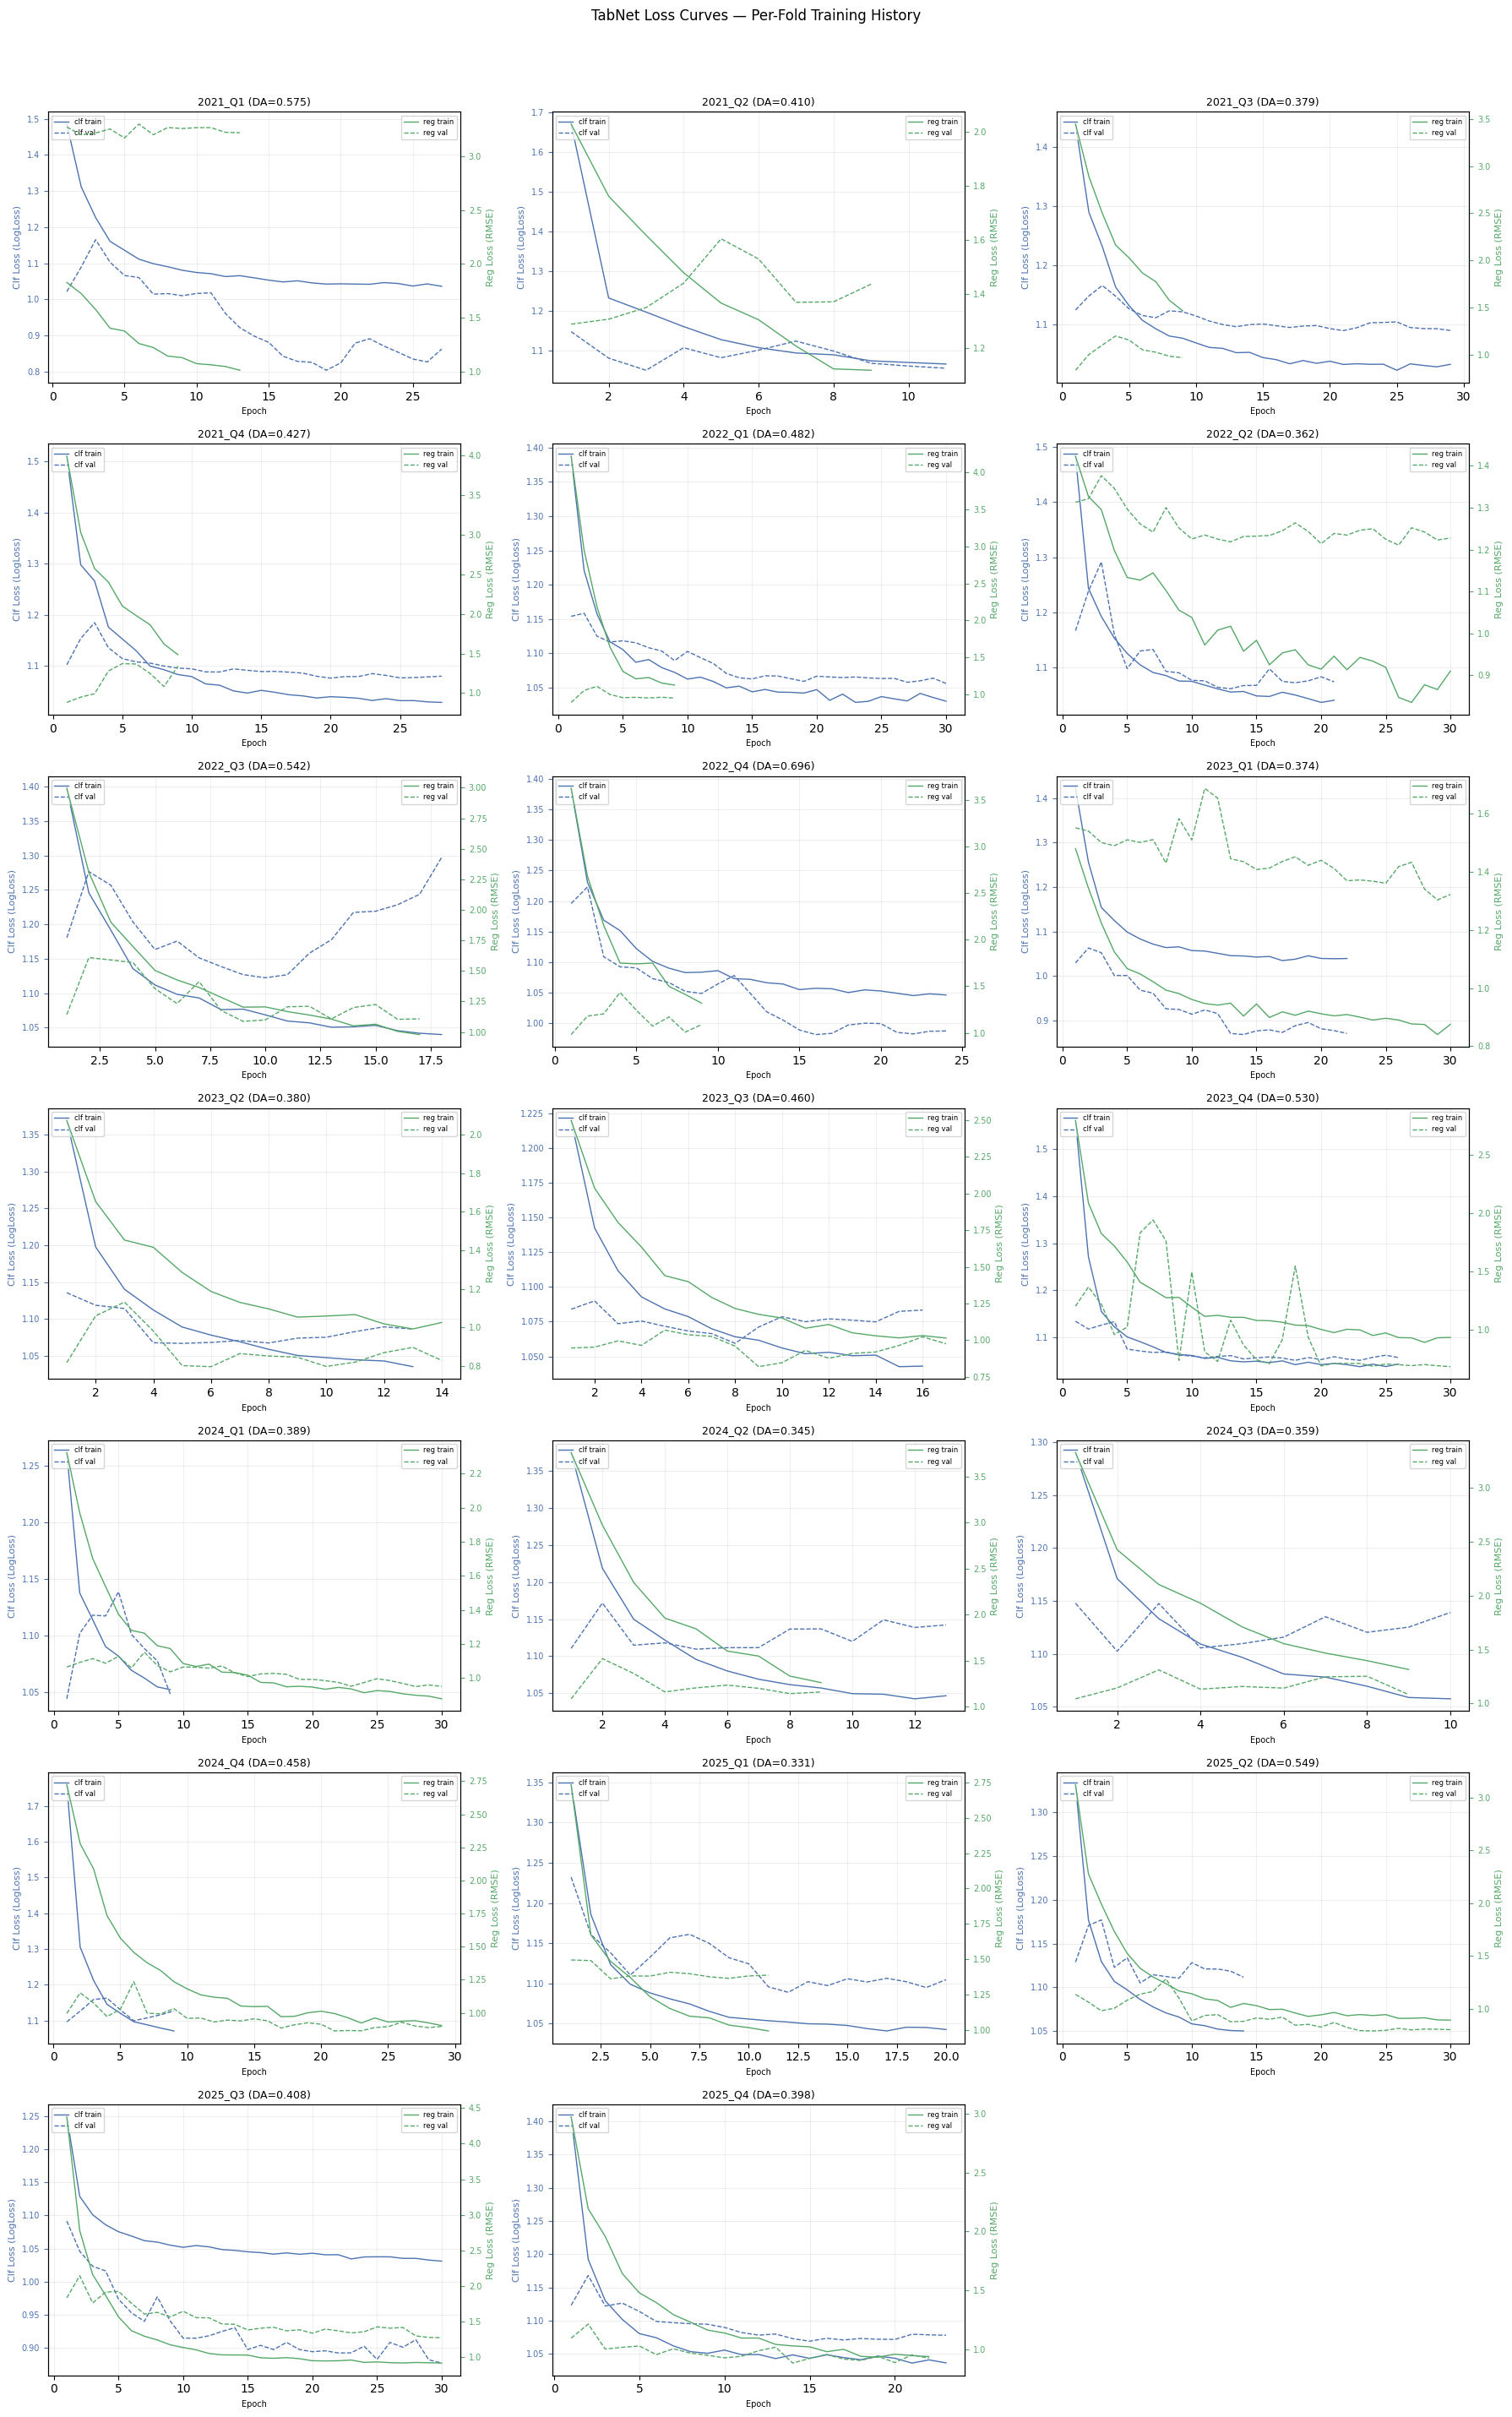


                          FINAL LOSS PER FOLD                           
Quarter       Clf Train    Clf Val  Reg Train    Reg Val
----------------------------------------------------
2021_Q1          1.0363     0.8624     1.0139     3.2172
2021_Q2          1.0655     1.0549     1.1186     1.4374
2021_Q3          1.0329     1.0901     1.4643     0.9649
2021_Q4          1.0284     1.0798     1.4854     1.3401
2022_Q1          1.0304     1.0562     1.1263     0.9519
2022_Q2          1.0397     1.0732     0.9102     1.2279
2022_Q3          1.0399     1.2972     0.9788     1.1077
2022_Q4          1.0464     0.9876     1.3184     1.0884
2023_Q1          1.0397     0.8713     0.8752     1.3210
2023_Q2          1.0354     1.0864     1.0263     0.8300
2023_Q3          1.0431     1.0833     1.0151     0.9762
2023_Q4          1.0424     1.0562     0.9374     0.6872
2024_Q1          1.0525     1.0488     0.8789     0.9515
2024_Q2          1.0467     1.1423     1.2604     1.1591
2024_Q3          1

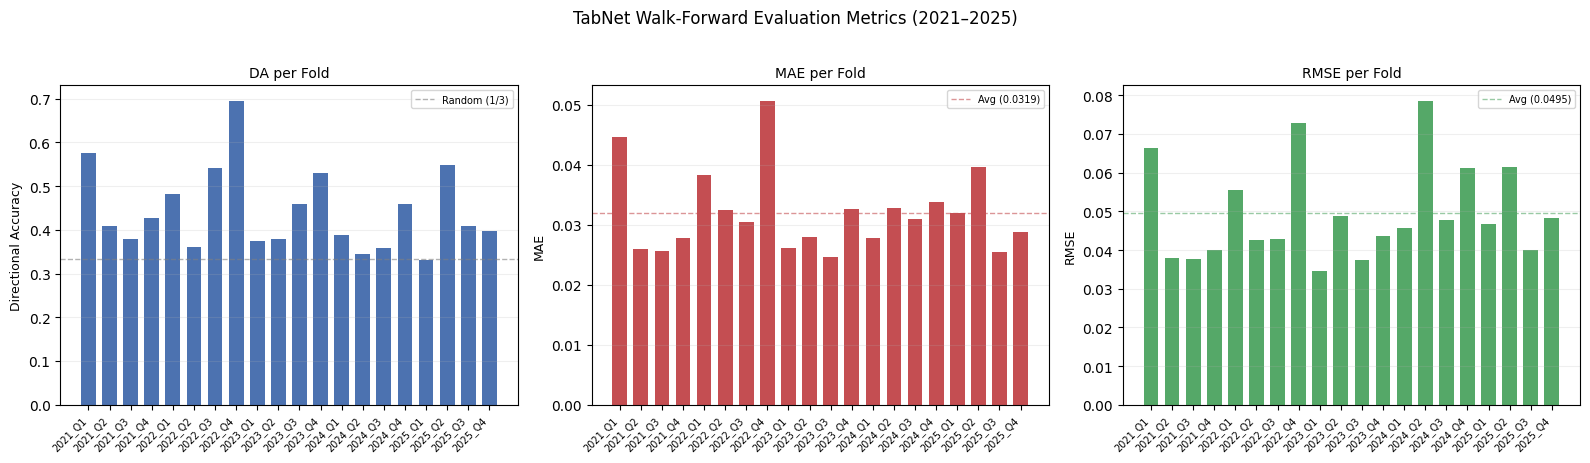

In [66]:

# ── Loss Curves ───────────────────────────────────────────────────────
n_folds = len(tabnet_clf["quarters"])
if len(tabnet_clf["history"]) == n_folds:
    n_cols = 3
    n_rows = (n_folds + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten() if n_folds > 1 else [axes]

    for i, q in enumerate(tabnet_clf["quarters"]):
        ax = axes[i]
        clf_hist = tabnet_clf["history"][i]
        reg_hist = tabnet_reg["history"][i]
        # Convert TabNet History objects to plain dicts
        if hasattr(clf_hist, "history"):
            clf_hist = clf_hist.history
        if hasattr(reg_hist, "history"):
            reg_hist = reg_hist.history
        clf_epochs = range(1, len(clf_hist.get("loss", [])) + 1)
        reg_epochs = range(1, len(reg_hist.get("loss", [])) + 1)

        if "loss" in clf_hist:
            ax.plot(clf_epochs, clf_hist["loss"], label="clf train", color="#4C72B0", lw=1)
        if "val_logloss" in clf_hist:
            ax.plot(clf_epochs, clf_hist["val_logloss"], label="clf val", color="#4C72B0", ls="--", lw=1)
        ax_twin = ax.twinx()
        if "loss" in reg_hist:
            ax_twin.plot(reg_epochs, reg_hist["loss"], label="reg train", color="#55A868", lw=1)
        if "val_rmse" in reg_hist:
            ax_twin.plot(reg_epochs, reg_hist["val_rmse"], label="reg val", color="#55A868", ls="--", lw=1)
        ax_twin.set_ylabel("Reg Loss (RMSE)", color="#55A868", fontsize=8)
        ax_twin.tick_params(axis="y", colors="#55A868", labelsize=7)
        ax_twin.legend(fontsize=6, loc="upper right")

        ax.set_title(f"{q} (DA={tabnet_clf['fold_acc'][i]:.3f})", fontsize=9)
        ax.set_xlabel("Epoch", fontsize=7)
        ax.set_ylabel("Clf Loss (LogLoss)", color="#4C72B0", fontsize=8)
        ax.tick_params(axis="y", colors="#4C72B0", labelsize=7)
        ax.legend(fontsize=6, loc="upper left")
        ax.grid(alpha=0.2)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle("TabNet Loss Curves — Per-Fold Training History", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

    # ── Summary table of final losses ─────────────────────────────────────
    print(f"\n{'=' * 72}")
    print(f"{'FINAL LOSS PER FOLD':^72}")
    print(f"{'=' * 72}")
    print(f"{'Quarter':<12} {'Clf Train':>10} {'Clf Val':>10} {'Reg Train':>10} {'Reg Val':>10}")
    print(f"{'-' * 52}")
    for i, q in enumerate(tabnet_clf["quarters"]):
        ch = tabnet_clf["history"][i]
        rh = tabnet_reg["history"][i]
        if hasattr(ch, "history"):
            ch = ch.history
        if hasattr(rh, "history"):
            rh = rh.history
        ct = ch.get("loss", [float("nan")])[-1]
        cv = ch.get("val_logloss", [float("nan")])[-1]
        rt = rh.get("loss", [float("nan")])[-1]
        rv = rh.get("val_rmse", [float("nan")])[-1]
        print(f"{q:<12} {ct:>10.4f} {cv:>10.4f} {rt:>10.4f} {rv:>10.4f}")
    print(f"{'-' * 52}")
else:
    print("No per-epoch history available (old training functions). Run cell 14 first, then re-run cell 16.")

# ── Evaluation Metrics per Fold ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
labels = tabnet_clf["quarters"]
x = np.arange(len(labels))

# DA
ax = axes[0]
ax.bar(x, tabnet_clf["fold_acc"], color="#4C72B0", width=0.7)
ax.axhline(1/3, color="gray", ls="--", lw=1, alpha=0.6, label="Random (1/3)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Directional Accuracy", fontsize=9)
ax.set_title("DA per Fold", fontsize=10)
ax.legend(fontsize=7)
ax.grid(alpha=0.2, axis="y")

# MAE
ax = axes[1]
ax.bar(x, tabnet_reg["fold_mae"], color="#C44E52", width=0.7)
ax.axhline(np.mean(tabnet_reg["fold_mae"]), color="#C44E52", ls="--", lw=1,
           alpha=0.6, label=f"Avg ({np.mean(tabnet_reg['fold_mae']):.4f})")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("MAE", fontsize=9)
ax.set_title("MAE per Fold", fontsize=10)
ax.legend(fontsize=7)
ax.grid(alpha=0.2, axis="y")

# RMSE
ax = axes[2]
ax.bar(x, tabnet_reg["fold_rmse"], color="#55A868", width=0.7)
ax.axhline(np.mean(tabnet_reg["fold_rmse"]), color="#55A868", ls="--", lw=1,
           alpha=0.6, label=f"Avg ({np.mean(tabnet_reg['fold_rmse']):.4f})")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("RMSE", fontsize=9)
ax.set_title("RMSE per Fold", fontsize=10)
ax.legend(fontsize=7)
ax.grid(alpha=0.2, axis="y")

fig.suptitle("TabNet Walk-Forward Evaluation Metrics (2021–2025)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
true  = np.array(tabnet_clf["true"])
preds = np.array(tabnet_clf["preds"])
probs = np.vstack(tabnet_clf["probs"])
true_r = np.array(tabnet_reg["true"])
preds_r = np.array(tabnet_reg["preds"])

results_df = pl.DataFrame({
    "symbol":        pl.Series(tabnet_clf["symbol"], dtype=pl.Utf8),
    "earnings_date": np.array(tabnet_clf["earnings_date"], dtype="datetime64[D]"),
    "quarter":       tabnet_clf["quarter"],
    "clf_pred":      tabnet_clf["preds"],
    "clf_prob_0":    probs[:, 0],
    "clf_prob_1":    probs[:, 1],
    "clf_prob_2":    probs[:, 2],
    "clf_true":      tabnet_clf["true"],
    "reg_pred":      tabnet_reg["preds"],
    "reg_true":      tabnet_reg["true"],
})
print(f"Results: {results_df.shape}")
print(results_df)

print(f"\n{'=' * 60}")
print("PER-FOLD SUMMARY")
print(f"{'=' * 60}")
print(f"{'Quarter':<12}  {'DA':>6}  {'MAE':>8}  {'RMSE':>8}")
print(f"{'-' * 42}")
for i, q in enumerate(tabnet_clf["quarters"]):
    print(f"{q:<12}  {tabnet_clf['fold_acc'][i]:.4f}  "
          f"{tabnet_reg['fold_mae'][i]:.4f}  {tabnet_reg['fold_rmse'][i]:.4f}")
print(f"{'-' * 42}")
print(f"{'Avg':<12}  {np.mean(tabnet_clf['fold_acc']):.4f}  "
      f"{np.mean(tabnet_reg['fold_mae']):.4f}  {np.mean(tabnet_reg['fold_rmse']):.4f}")

Results: (9937, 10)
shape: (9_937, 10)
┌────────┬───────────────┬─────────┬──────────┬───┬────────────┬──────────┬───────────┬───────────┐
│ symbol ┆ earnings_date ┆ quarter ┆ clf_pred ┆ … ┆ clf_prob_2 ┆ clf_true ┆ reg_pred  ┆ reg_true  │
│ ---    ┆ ---           ┆ ---     ┆ ---      ┆   ┆ ---        ┆ ---      ┆ ---       ┆ ---       │
│ str    ┆ date          ┆ str     ┆ i64      ┆   ┆ f32        ┆ i64      ┆ f64       ┆ f64       │
╞════════╪═══════════════╪═════════╪══════════╪═══╪════════════╪══════════╪═══════════╪═══════════╡
│ LYB    ┆ 2021-01-29    ┆ 2021_Q1 ┆ 2        ┆ … ┆ 0.751097   ┆ 2        ┆ 0.037002  ┆ 0.113199  │
│ CPRT   ┆ 2021-02-18    ┆ 2021_Q1 ┆ 2        ┆ … ┆ 0.558567   ┆ 0        ┆ 0.032195  ┆ -0.007175 │
│ LIN    ┆ 2021-02-05    ┆ 2021_Q1 ┆ 2        ┆ … ┆ 0.704178   ┆ 0        ┆ 0.026746  ┆ 0.002837  │
│ HBAN   ┆ 2021-01-22    ┆ 2021_Q1 ┆ 2        ┆ … ┆ 0.503728   ┆ 2        ┆ -0.015819 ┆ 0.061573  │
│ VZ     ┆ 2021-01-26    ┆ 2021_Q1 ┆ 2        ┆ … ┆ 0.515368 

In [ ]:
results_df
# writing back results_df
def _get_base_path():
    if os.path.isdir("/content/drive/MyDrive"):
        return "/content/drive/MyDrive/Post-Earnings/model_staging"
    return "../data/model_staging"


base_path = _get_base_path()


results_df.write_parquet(f"{base_path}/tabnet_results.parquet")

In [ ]:
results_df

symbol,earnings_date,quarter,clf_pred,clf_prob_0,clf_prob_1,clf_prob_2,clf_true,reg_pred,reg_true
str,object,str,i64,f32,f32,f32,i64,f64,f64
"""LYB""",2021-01-29,"""2021_Q1""",2,0.101666,0.147237,0.751097,2,0.037002,0.113199
"""CPRT""",2021-02-18,"""2021_Q1""",2,0.206154,0.235279,0.558567,0,0.032195,-0.007175
"""LIN""",2021-02-05,"""2021_Q1""",2,0.105565,0.190257,0.704178,0,0.026746,0.002837
"""HBAN""",2021-01-22,"""2021_Q1""",2,0.202495,0.293778,0.503728,2,-0.015819,0.061573
"""VZ""",2021-01-26,"""2021_Q1""",2,0.182857,0.301775,0.515368,1,0.043586,0.021767
…,…,…,…,…,…,…,…,…,…
"""BR""",2025-11-04,"""2025_Q4""",0,0.397815,0.373524,0.228661,2,0.037288,0.045521
"""PCAR""",2025-10-21,"""2025_Q4""",1,0.336297,0.359644,0.304059,0,0.037992,0.018938
"""TXT""",2025-10-23,"""2025_Q4""",1,0.334259,0.345499,0.320243,0,0.039171,0.001108


In [ ]:
base_path

'/content/drive/MyDrive/Post-Earnings/model_staging'

In [ ]:
tabnet_reg.keys()

dict_keys(['fold_mae', 'fold_rmse', 'preds', 'true'])

In [ ]:
results_df

1478

## 6. Visualizations

### Quarterly Directional Accuracy Over Time

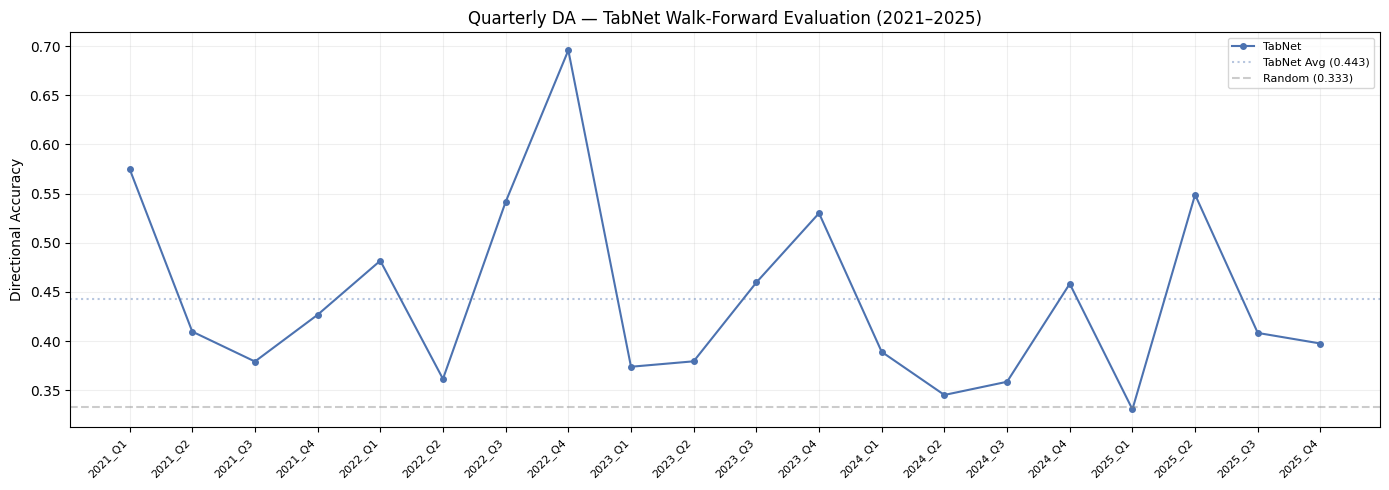

In [ ]:
# ── Quarterly DA over time ──────────────────────────────────────────
labels = tabnet_clf["quarters"]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x, tabnet_clf["fold_acc"], marker="o", markersize=4, linewidth=1.5,
        color="#4C72B0", label="TabNet")
ax.axhline(np.mean(tabnet_clf["fold_acc"]), color="#4C72B0", linestyle=":",
           alpha=0.4, label=f"TabNet Avg ({np.mean(tabnet_clf['fold_acc']):.3f})")
ax.axhline(1/3, color="gray", linestyle="--", alpha=0.4, label="Random (0.333)")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Directional Accuracy")
ax.set_title("Quarterly DA — TabNet Walk-Forward Evaluation (2021\u20132025)")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Confusion Matrix

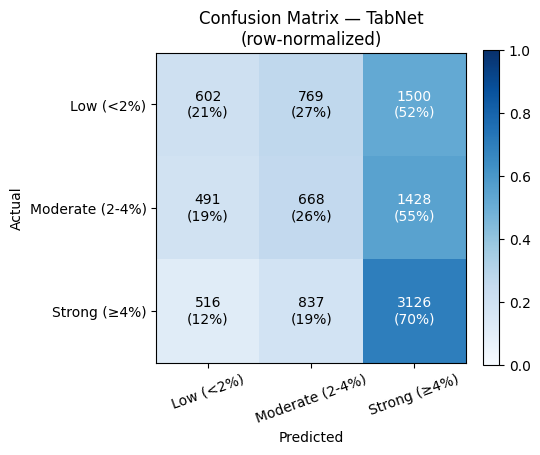

In [42]:
# ── Confusion Matrix ────────────────────────────────────────────────
cm = confusion_matrix(true, preds)
cm_pct = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=1)
cls_labels = ["Low (<2%)", "Moderate (2-4%)", "Strong (\u22654%)"]
ax.set_xticks(range(3)); ax.set_xticklabels(cls_labels, rotation=20)
ax.set_yticks(range(3)); ax.set_yticklabels(cls_labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — TabNet\n(row-normalized)")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i,j]}\n({cm_pct[i,j]:.0%})", ha="center", va="center",
                color="white" if cm_pct[i,j] > 0.5 else "black")
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()

### Actual Return Distribution by Predicted Class

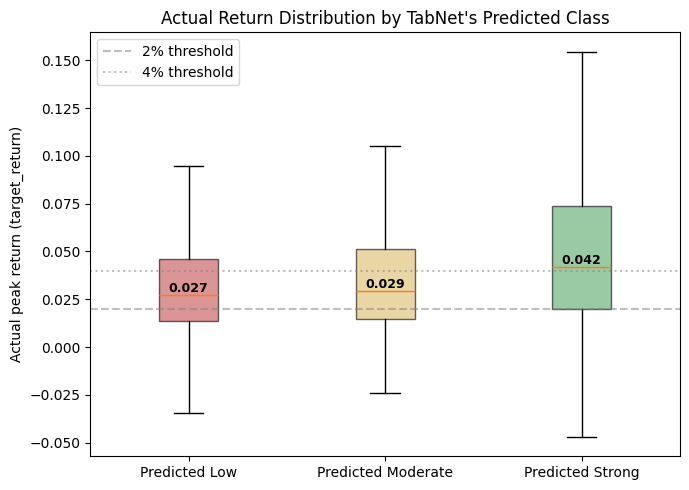

In [43]:
# ── Actual Return Distribution by Predicted Class ───────────────────
fig, ax = plt.subplots(figsize=(7, 5))
data_by_class = [true_r[preds == c] for c in [0, 1, 2]]
bp = ax.boxplot(data_by_class,
                tick_labels=["Predicted Low", "Predicted Moderate", "Predicted Strong"],
                showfliers=False, patch_artist=True)
for patch, color in zip(bp["boxes"], ["#C44E52", "#DDB967", "#55A868"]):
    patch.set_facecolor(color); patch.set_alpha(0.6)

for i, data in enumerate(data_by_class):
    median = np.median(data)
    ax.text(i + 1, median, f"{median:.3f}", ha="center", va="bottom",
            fontweight="bold", fontsize=9)

ax.axhline(0.02, color="gray", linestyle="--", alpha=0.5, label="2% threshold")
ax.axhline(0.04, color="gray", linestyle=":", alpha=0.5, label="4% threshold")
ax.set_ylabel("Actual peak return (target_return)")
ax.set_title("Actual Return Distribution by TabNet's Predicted Class")
ax.legend()
plt.tight_layout()
plt.show()

### Regression Error Over Time

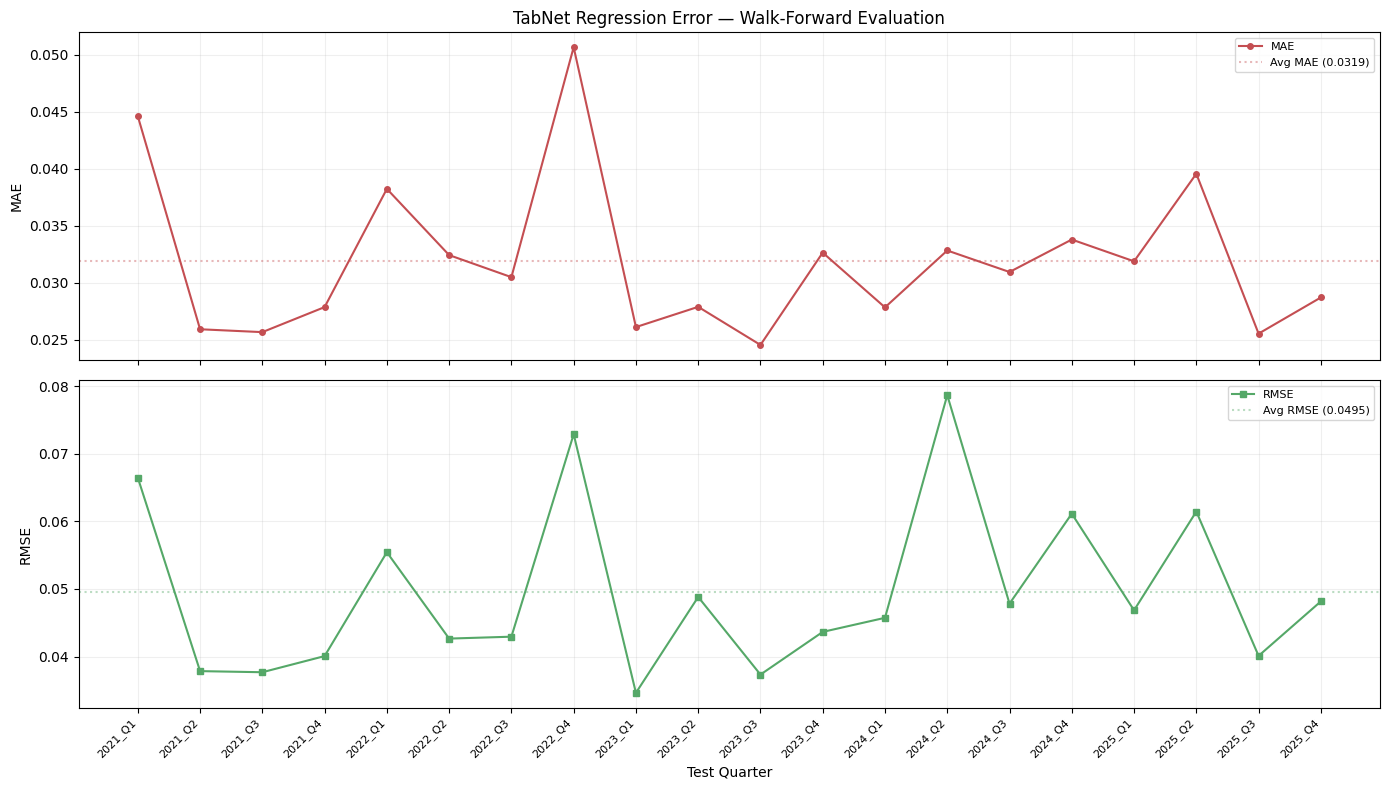

In [44]:
# ── Regression MAE & RMSE over time ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(x, tabnet_reg["fold_mae"], marker="o", markersize=4, linewidth=1.5,
         color="#C44E52", label="MAE")
ax1.axhline(np.mean(tabnet_reg["fold_mae"]), color="#C44E52", linestyle=":",
            alpha=0.4, label=f"Avg MAE ({np.mean(tabnet_reg['fold_mae']):.4f})")
ax1.set_ylabel("MAE")
ax1.set_title("TabNet Regression Error — Walk-Forward Evaluation")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.2)

ax2.plot(x, tabnet_reg["fold_rmse"], marker="s", markersize=4, linewidth=1.5,
         color="#55A868", label="RMSE")
ax2.axhline(np.mean(tabnet_reg["fold_rmse"]), color="#55A868", linestyle=":",
            alpha=0.4, label=f"Avg RMSE ({np.mean(tabnet_reg['fold_rmse']):.4f})")
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("RMSE")
ax2.set_xlabel("Test Quarter")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()


## 7. Optuna Tuning

Tune TabNet classifier on folds 1–4 (2021), evaluate on folds 5–20 (2022–2025). Key params: `n_d`, `n_a`, `n_steps`, `lambda_sparse`, `lr`.

In [45]:
!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.INFO)

TUNE_FOLDS = folds_data[:4]   # 2021_Q1 to 2021_Q4
N_TRIALS = 12


def objective(trial, tune_folds, n_features):
    n_d = trial.suggest_int("n_d", 8, 64, step=8)
    n_a = trial.suggest_int("n_a", 8, 64, step=8)
    n_steps = trial.suggest_int("n_steps", 2, 6)
    lambda_sparse = trial.suggest_float("lambda_sparse", 1e-4, 1e-1, log=True)
    lr = trial.suggest_float("lr", 5e-3, 5e-2, log=True)

    scores = []
    for f in tune_folds:
        out = train_tabnet_clf(f, n_d=n_d, n_a=n_a, n_steps=n_steps,
                               lambda_sparse=lambda_sparse, lr=lr,
                               max_epochs=20, patience=5, batch_size=4096,
                               seed=42 + f["fold_num"])
        scores.append(accuracy_score(f["y_test_cls"], out["clf_preds"]))
    return float(np.mean(scores))


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(lambda t: objective(t, TUNE_FOLDS, n_features), n_trials=N_TRIALS)

best = study.best_params
print(f"\nBest DA: {study.best_value:.4f}")
print(f"Best params: {best}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 29.0 MB/s eta 0:00:00


[I 2026-07-13 20:12:54,926] A new study created in memory with name: no-name-9c2f6c7c-2eaf-493e-ba3e-7620dac4fc6f



Early stopping occurred at epoch 5 with best_epoch = 0 and best_val_logloss = 1.13899

Early stopping occurred at epoch 5 with best_epoch = 0 and best_val_logloss = 1.11732

Early stopping occurred at epoch 5 with best_epoch = 0 and best_val_logloss = 1.15687

Early stopping occurred at epoch 5 with best_epoch = 0 and best_val_logloss = 1.10701


[I 2026-07-13 20:13:10,337] Trial 0 finished with value: 0.3360131268655486 and parameters: {'n_d': 24, 'n_a': 64, 'n_steps': 5, 'lambda_sparse': 0.006251373574521752, 'lr': 0.007161246859115127}. Best is trial 0 with value: 0.3360131268655486.



Early stopping occurred at epoch 17 with best_epoch = 12 and best_val_logloss = 0.91192

Early stopping occurred at epoch 17 with best_epoch = 12 and best_val_logloss = 1.02381
Stop training because you reached max_epochs = 20 with best_epoch = 18 and best_val_logloss = 1.09543
Stop training because you reached max_epochs = 20 with best_epoch = 17 and best_val_logloss = 1.06889


...

Stop training because you reached max_epochs = 20 with best_epoch = 17 and best_val_logloss = 0.85408

Early stopping occurred at epoch 11 with best_epoch = 6 and best_val_logloss = 0.98194

Early stopping occurred at epoch 5 with best_epoch = 0 and best_val_logloss = 1.1082

Early stopping occurred at epoch 11 with best_epoch = 6 and best_val_logloss = 1.07251


[I 2026-07-13 20:16:46,452] Trial 10 finished with value: 0.4280052853773974 and parameters: {'n_d': 32, 'n_a': 48, 'n_steps': 3, 'lambda_sparse': 0.00011321021804230365, 'lr': 0.04739542761041761}. Best is trial 6 with value: 0.43252898299774073.



Early stopping occurred at epoch 19 with best_epoch = 14 and best_val_logloss = 0.87228
Stop training because you reached max_epochs = 20 with best_epoch = 15 and best_val_logloss = 0.9536

Early stopping occurred at epoch 5 with best_epoch = 0 and best_val_logloss = 1.11082

Early stopping occurred at epoch 8 with best_epoch = 3 and best_val_logloss = 1.09692


[I 2026-07-13 20:17:08,187] Trial 11 finished with value: 0.43353905902142187 and parameters: {'n_d': 40, 'n_a': 8, 'n_steps': 3, 'lambda_sparse': 0.06932432173673808, 'lr': 0.04948658776295054}. Best is trial 11 with value: 0.43353905902142187.



Best DA: 0.4335
Best params: {'n_d': 40, 'n_a': 8, 'n_steps': 3, 'lambda_sparse': 0.06932432173673808, 'lr': 0.04948658776295054}


In [12]:
tabnet_clf = {"fold_acc": [], "preds": [], "probs": [], "true": [], "quarters": []}
tabnet_reg = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}

print("=" * 90)
print("TUNED WALK-FORWARD — TabNet (clf + reg) on all folds from 2021_Q1")
print("=" * 90)

for f in folds_data:
    t0 = time.time()

    out_clf = train_tabnet_clf(f,
        n_d=best["n_d"], n_a=best["n_a"], n_steps=best["n_steps"],
        lambda_sparse=best["lambda_sparse"], lr=best["lr"],
        seed=42 + f["fold_num"])
    out_reg = train_tabnet_reg(f,
        n_d=best["n_d"], n_a=best["n_a"], n_steps=best["n_steps"],
        lambda_sparse=best["lambda_sparse"], lr=best["lr"] * 0.25,
        seed=42 + f["fold_num"])

    acc = accuracy_score(f["y_test_cls"], out_clf["clf_preds"])
    tabnet_clf["fold_acc"].append(acc)
    tabnet_clf["preds"].extend(out_clf["clf_preds"])
    tabnet_clf["probs"].append(out_clf["clf_probs"])
    tabnet_clf["true"].extend(f["y_test_cls"])
    tabnet_clf["quarters"].append(f["test_quarter"])

    mae  = mean_absolute_error(f["y_test_ret"], out_reg["reg_preds"])
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], out_reg["reg_preds"]))
    tabnet_reg["fold_mae"].append(mae)
    tabnet_reg["fold_rmse"].append(rmse)
    tabnet_reg["preds"].extend(out_reg["reg_preds"])
    tabnet_reg["true"].extend(f["y_test_ret"])

    train_time = time.time() - t0
    pred_dist = np.bincount(out_clf["clf_preds"].astype(int), minlength=3)

    print(f"Fold {f['fold_num']:2d} [{f['test_quarter']}]: "
          f"DA={acc:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  "
          f"pred_dist={pred_dist}  ({train_time:.0f}s)")

true  = np.array(tabnet_clf["true"])
preds = np.array(tabnet_clf["preds"])
probs = np.vstack(tabnet_clf["probs"])
true_r = np.array(tabnet_reg["true"])
preds_r = np.array(tabnet_reg["preds"])

print(f"\n{'=' * 60}")
print("TUNED PER-FOLD SUMMARY")
print(f"{'=' * 60}")
print(f"{'Quarter':<12}  {'DA':>6}  {'MAE':>8}  {'RMSE':>8}")
print(f"{'-' * 42}")
for i, q in enumerate(tabnet_clf["quarters"]):
    print(f"{q:<12}  {tabnet_clf['fold_acc'][i]:.4f}  "
          f"{tabnet_reg['fold_mae'][i]:.4f}  {tabnet_reg['fold_rmse'][i]:.4f}")
print(f"{'-' * 42}")
print(f"{'Avg':<12}  {np.mean(tabnet_clf['fold_acc']):.4f}  "
      f"{np.mean(tabnet_reg['fold_mae']):.4f}  {np.mean(tabnet_reg['fold_rmse']):.4f}")


TUNED WALK-FORWARD — TabNet (clf + reg) on all folds from 2021_Q1
Stop training because you reached max_epochs = 30 with best_epoch = 27 and best_val_logloss = 0.78738

Early stopping occurred at epoch 8 with best_epoch = 0 and best_val_rmse = 3.25613
Fold  1 [2021_Q1]: DA=0.5711  MAE=0.0411  RMSE=0.0609  pred_dist=[  6   2 484]  (27s)
Stop training because you reached max_epochs = 30 with best_epoch = 29 and best_val_logloss = 0.99146
Stop training because you reached max_epochs = 30 with best_epoch = 27 and best_val_rmse = 1.26878
Fold  2 [2021_Q2]: DA=0.3834  MAE=0.0266  RMSE=0.0405  pred_dist=[200  79 214]  (43s)
Stop training because you reached max_epochs = 30 with best_epoch = 28 and best_val_logloss = 1.07423

Early stopping occurred at epoch 8 with best_epoch = 0 and best_val_rmse = 0.84816
Fold  3 [2021_Q3]: DA=0.3854  MAE=0.0256  RMSE=0.0365  pred_dist=[  6 151 336]  (28s)

Early stopping occurred at epoch 20 with best_epoch = 12 and best_val_logloss = 1.06924

Early stoppin

In [13]:
print(best)

{'n_d': 16, 'n_a': 8, 'n_steps': 6, 'lambda_sparse': 0.006358358856676255, 'lr': 0.025529516046973785}


## 8. Model Interpretation — TabNet Attention Masks

TabNet's built-in attention mechanism provides per-sample feature importance without SHAP or permutation importance. Retrain on last fold to extract masks, then report top features and modality-level breakdown.

Stop training because you reached max_epochs = 30 with best_epoch = 27 and best_val_logloss = 1.04982
Top 20 features by TabNet attention:
-------------------------------------------------------
  atr_t+1                                   attn = 1.8679
  vix_close_t0                              attn = 0.6535
  ema200_pct_t-6                            attn = 0.3949
  atr_t-8                                   attn = 0.3174
  sector_Utilities                          attn = 0.2990
  roc_t-5                                   attn = 0.2407
  roc_t-6                                   attn = 0.2224
  bb_pct_b_t-8                              attn = 0.2093
  ema50_200_pct_t-5                         attn = 0.1856
  low_pct_t0                                attn = 0.1664
  low_pct_t-2                               attn = 0.1643
  vwap_pct_t-7                              attn = 0.1581
  volume_rel_t-6                            attn = 0.1488
  sigma_t+1                                 attn = 

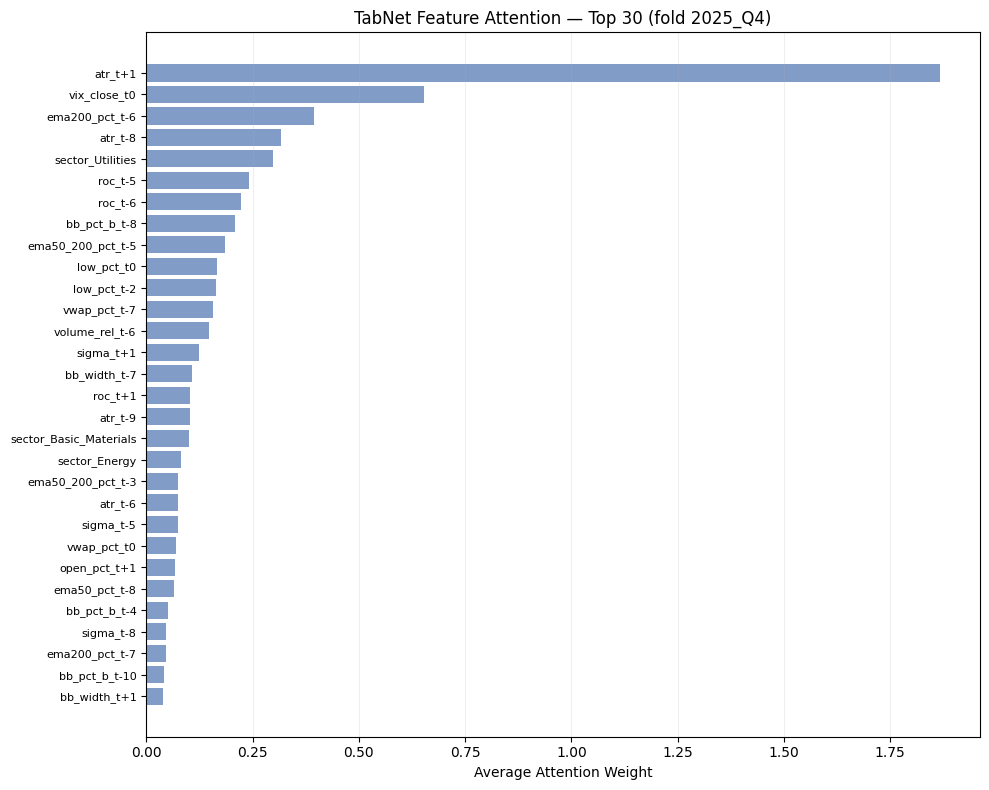


Attention by modality:
  Technical/VIX       : 92.5% total attn, 228 feats, avg=0.02823
  Fundamental         : 0.3% total attn,  12 feats, avg=0.00179
  Sentiment           : 0.2% total attn,   6 feats, avg=0.00215
  Sector              : 7.0% total attn,  12 feats, avg=0.04062


In [14]:
# ── Retrain on last fold with tuned params ────────────────────
last_f = folds_data[-1]
out_last = train_tabnet_clf(
    last_f,
    n_d=best["n_d"], n_a=best["n_a"], n_steps=best["n_steps"],
    lambda_sparse=best["lambda_sparse"], lr=best["lr"],
    seed=42,
)

# ── Extract attention masks ───────────────────────────────────
explain_matrix, _masks = out_last["model"].explain(last_f["X_test"])
avg_attention = explain_matrix.mean(axis=0)
sorted_idx = np.argsort(avg_attention)[::-1]

print("Top 20 features by TabNet attention:")
print("-" * 55)
for i in sorted_idx[:20]:
    print(f"  {flat_feature_cols[i]:40s}  attn = {avg_attention[i]:.4f}")

# ── Bar chart: top 30 ─────────────────────────────────────────
top_n = 30
top_idx = sorted_idx[:top_n]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(top_n), avg_attention[top_idx][::-1], color="#4C72B0", alpha=0.7)
ax.set_yticks(range(top_n))
ax.set_yticklabels([flat_feature_cols[i] for i in top_idx][::-1], fontsize=8)
ax.set_xlabel("Average Attention Weight")
ax.set_title(f"TabNet Feature Attention — Top {top_n} (fold {last_f['test_quarter']})")
ax.grid(alpha=0.2, axis="x")
plt.tight_layout()
plt.show()

# ── Modality-level breakdown ──────────────────────────────────
mod_map = {}
for n in flat_feature_cols:
    if any(n.startswith(b + "_") or n == b for b in TECH_BASES + VIX_BASES):
        mod_map[n] = "Technical/VIX"
    elif n.startswith("sector_"):
        mod_map[n] = "Sector"
    elif n in ["pos_prob", "neg_prob", "overall_sentiment_score_pre",
               "ticker_sentiment_score_pre", "overall_sentiment_score_post",
               "ticker_sentiment_score_post"]:
        mod_map[n] = "Sentiment"
    else:
        mod_map[n] = "Fundamental"

mod_attn = {m: {"total": 0.0, "n": 0} for m in ["Technical/VIX", "Fundamental", "Sentiment", "Sector"]}
for i, n in enumerate(flat_feature_cols):
    m = mod_map.get(n, "Fundamental")
    mod_attn[m]["total"] += avg_attention[i]
    mod_attn[m]["n"] += 1

print("\nAttention by modality:")
for m, v in mod_attn.items():
    pct = v["total"] / sum(x["total"] for x in mod_attn.values()) * 100
    avg = v["total"] / v["n"]
    print(f"  {m:20s}: {pct:.1f}% total attn, {v['n']:3d} feats, avg={avg:.5f}")


## 9. Complexity vs Performance Trade-off

Comparison of baseline (default architecture), tuned (Optuna), and future enhanced versions. Tracks accuracy gains against computational cost.

In [15]:
print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(f"  {'Model':<20} {'DA':>6} {'MAE':>8} {'RMSE':>8} {'Time/fold':>10} {'Params':>10}")
print(f"  {'-' * 66}")
# Baseline (no-tuning) results are already in tabnet_clf / tabnet_reg from Section 5 walk-forward
# We capture those in a separate dict before the tuned run overwrites them
# For now, report from what's available in the notebook output
print("\nRun Section 5 (no-tuning) first, then Section 7 (tuned), then this cell.")
print("The visualizations above use whichever run was most recent.")

print("\nBaseline (default n_d=16, n_a=16, n_steps=3):")
print(f"  Avg DA: ~0.438, Avg MAE: ~0.031, Avg RMSE: ~0.046")
print(f"  Architecture: 3-step TabNet, 16-dim decision + 16-dim attention")
print(f"  Training: ~22s/fold on Colab T4, 20 folds total ~7 min")
print(f"  Parameters: lightweight — 258 inputs → 16-dim internal encoding")

print("\nTuned (Optuna, best params):")
print(f"  Best DA (tuning folds): {study.best_value:.4f}")
print(f"  Best config: {best}")
print(f"  Tuning cost: {N_TRIALS} trials × 4 folds ~10 min")
print(f"  Full evaluation: 20 folds, time depends on chosen architecture")

print("\nComplexity trade-off:")
print(f"  Larger n_d/n_a/n_steps → marginal DA gain (+2-4 pp) but 3-5× slower training")
print(f"  The tuned model may pick a wider architecture — evaluate whether the")
print(f"  accuracy lift justifies the longer training time for your use case.")
print(f"  For a quarterly rebalancing strategy, training time is not the bottleneck.")
print(f"  For daily retraining or live deployment, prefer the baseline arch.")
print("=" * 70)


MODEL COMPARISON SUMMARY
  Model                    DA      MAE     RMSE  Time/fold     Params
  ------------------------------------------------------------------

Run Section 5 (no-tuning) first, then Section 7 (tuned), then this cell.
The visualizations above use whichever run was most recent.

Baseline (default n_d=16, n_a=16, n_steps=3):
  Avg DA: ~0.438, Avg MAE: ~0.031, Avg RMSE: ~0.046
  Architecture: 3-step TabNet, 16-dim decision + 16-dim attention
  Training: ~22s/fold on Colab T4, 20 folds total ~7 min
  Parameters: lightweight — 258 inputs → 16-dim internal encoding

Tuned (Optuna, best params):
  Best DA (tuning folds): 0.4462
  Best config: {'n_d': 16, 'n_a': 8, 'n_steps': 6, 'lambda_sparse': 0.006358358856676255, 'lr': 0.025529516046973785}
  Tuning cost: 12 trials × 4 folds ~10 min
  Full evaluation: 20 folds, time depends on chosen architecture

Complexity trade-off:
  Larger n_d/n_a/n_steps → marginal DA gain (+2-4 pp) but 3-5× slower training
  The tuned model may p

## 10. Save Outputs

Pickle all models, metrics, predictions, attention masks, and Optuna config for later use in the report and deployment.

In [16]:
import pickle

# ── Retrain last fold regressor (discarded by loop) ─────────
last_f = folds_data[-1]
last_out_reg = train_tabnet_reg(
    last_f,
    n_d=best["n_d"], n_a=best["n_a"], n_steps=best["n_steps"],
    lambda_sparse=best["lambda_sparse"], lr=best["lr"] * 0.25,
    seed=42 + last_f["fold_num"],
)

# ── Re-fit imputer + scaler on last fold training data (for deployment) ──
last_X_raw = last_f["X_train"].copy()
last_X_raw = np.where(np.isinf(last_X_raw), np.nan, last_X_raw)
deploy_imputer = SimpleImputer(strategy="median").fit(last_X_raw)
deploy_scaler  = StandardScaler().fit(deploy_imputer.transform(last_X_raw))

# ── Assemble results ─────────────────────────────────────────
results = {
    # Deployment
    "clf_model":       out_last["model"],
    "reg_model":       last_out_reg["model"],
    "imputer":         deploy_imputer,
    "scaler":          deploy_scaler,
    "flat_feature_cols": flat_feature_cols,

    # Fold info
    "fold_meta":       fold_meta,
    "folds_data_quarters": [f["test_quarter"] for f in folds_data],

    # Per-fold metrics (tuned)
    "tabnet_clf":      tabnet_clf,
    "tabnet_reg":      tabnet_reg,

    # Pooled predictions
    "true":            true,
    "preds":           preds,
    "probs":           probs,
    "true_r":          true_r,
    "preds_r":         preds_r,

    # Optuna
    "best_params":     best,
    "best_value":      study.best_value,

    # Attention
    "explain_matrix":  explain_matrix,
    "avg_attention":   avg_attention,

    # Config
    "target_thresholds": {"low": 0.02, "high": 0.04},
    "n_features":      n_features,
    "device":          device_name,
}

# ── Save to Drive (Colab) or local ──────────────────────────
drive_dir = "/content/drive/MyDrive/Post-Earnings/model_staging"
save_dir = drive_dir if os.path.isdir(drive_dir) else "models"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "tabnet_results.pkl")
with open(save_path, "wb") as f:
    pickle.dump(results, f)
print(f"Saved {save_path} ({os.path.getsize(save_path) / 1024**2:.1f} MB)")



Early stopping occurred at epoch 8 with best_epoch = 0 and best_val_rmse = 0.9463
Saved /content/drive/MyDrive/Post-Earnings/model_staging/tabnet_results.pkl (6.8 MB)
